# **Project Title: Auto Tagging Customer Support ticket Using LLM**

# Submitted by: Afeera Sagheer

# **Project Description:**
This project uses a Large Language Model (LLM) to automatically classify customer support tickets into relevant categories such as Technical Issue, Billing Inquiry, Refund Request, Product Inquiry, and Cancellation Request. The system analyzes the text in each support ticket and predicts the most appropriate tags, reducing the need for manual ticket categorization and improving support workflow efficiency.

The project implements zero-shot and few-shot learning techniques to compare classification performance without extensive model training. For each ticket, the model generates the top three most probable tags, helping support teams route customer requests to the correct department more quickly. The solution is evaluated using metrics such as Accuracy and F1-Score and is deployed through a Gradio web interface for real-time user interaction.

# **1_ Importing Libraries**

In [ ]:
# importing pandas for data cleaning and manipulation
import pandas as pd
# numpy for statistical operations
import numpy as np

# matplotlib for visualization and seaborn also for advanced visualization
import matplotlib.pyplot as plt
import seaborn as sns

# importing train test split to seperate training and testing data
from sklearn.model_selection import train_test_split
# labelEncoder for coverting text labels into numeric values
from sklearn.preprocessing import LabelEncoder

# importing accuracy score for checking model accuracy, classification report, confusion matrix for model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# pipeline for code efficiency
from transformers import pipeline
# gradio to create simple web applications
import gradio as gr

# **2_ Loading Dataset**

In [ ]:
# loading dataset and checking first five rows
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/customer_support_tickets.csv')
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


# **3_ Data Inspection**

In [ ]:
# checking last five rows
df.tail()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0
8468,8469,Steven Davis MD,lori20@example.net,53,Other,Philips Hue Lights,2020-06-01,Billing inquiry,Hardware issue,There seems to be a hardware problem with my {...,Open,NaN,High,Phone,NaN,NaN,NaN


In [ ]:
# checking mean, median, std, max ,min
df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [ ]:
# checking the number of values
df.shape

(8469, 17)

In [ ]:
# checking rows and columns
df.size

143973

In [ ]:
# checking column names
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [ ]:
# checking data types
df.dtypes


,0
Ticket ID,int64
Customer Name,object
Customer Email,object
Customer Age,int64
Customer Gender,object
Product Purchased,object
Date of Purchase,object
Ticket Type,object
Ticket Subject,object
Ticket Description,object


In [ ]:
# checking not null enteries, datatypes
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

# **4_ Data Cleaning**

In [ ]:
# checking null enteries in each column
print(df.isnull().sum())

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


In [ ]:
# checking null enteries in dataset
df.isnull()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True
1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,True
8465,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,True
8466,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8467,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# checking enteries that are not null in dataset
df.notnull()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True,False,False
1,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True,False,False
2,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,True,True,True,True,True,True,True,True,True,True,True,False,True,True,False,False,False
8465,True,True,True,True,True,True,True,True,True,True,True,False,True,True,False,False,False
8466,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
8467,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [ ]:
# checking enteries that are not null in each column
df.notnull().sum()

,0
Ticket ID,8469
Customer Name,8469
Customer Email,8469
Customer Age,8469
Customer Gender,8469
Product Purchased,8469
Date of Purchase,8469
Ticket Type,8469
Ticket Subject,8469
Ticket Description,8469


In [ ]:
df = df[
    [
        "Ticket Description",
        "Ticket Type"
    ]
]

In [ ]:
# it drops irrelevant columns
df.dropna(inplace=True)

print(df.shape)

(8469, 2)


In [ ]:
# checking value counts
print(
    df["Ticket Type"].value_counts()
)

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


# **5_ Numerical Operations**

In [ ]:
df.std(numeric_only=True)

,0


In [ ]:
# checking middle value
df.median(numeric_only=True)

,0


In [ ]:
# checking average value
df.mean(numeric_only=True)

,0


In [ ]:
# varriance is the square of std
df.var(numeric_only=True)

,0


In [ ]:
# checking maximum value
df.max(numeric_only=True)

,0


In [ ]:
# checking minimum value
df.min(numeric_only = True)

,0


# **6_ Visualization**

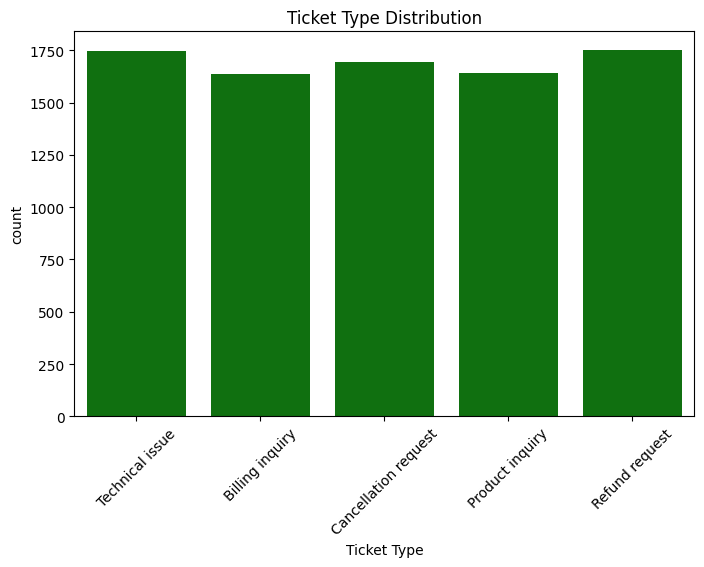

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Ticket Type", color = 'green'
)

plt.xticks(rotation=45)

plt.title("Ticket Type Distribution")

plt.show()

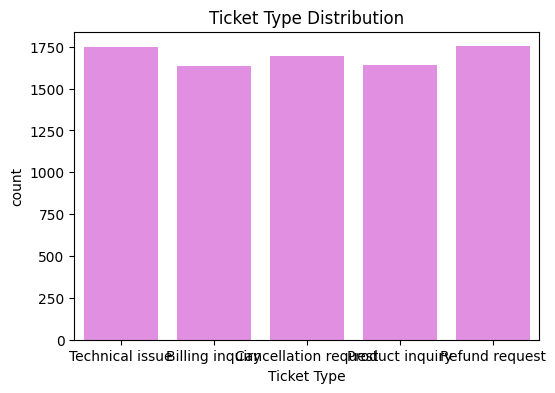

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Ticket Type', color = 'violet')
plt.title('Ticket Type Distribution')
plt.show()

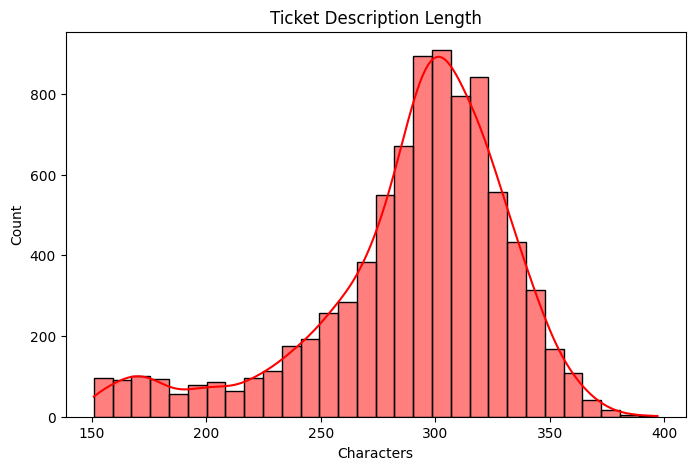

In [ ]:
df['Description Length'] = (
    df['Ticket Description']
    .astype(str)
    .apply(len)
)

plt.figure(figsize=(8,5))

sns.histplot(
    df['Description Length'],
    bins=30,
    kde=True,
    color = 'red'
)

plt.title('Ticket Description Length')
plt.xlabel('Characters')
plt.show()

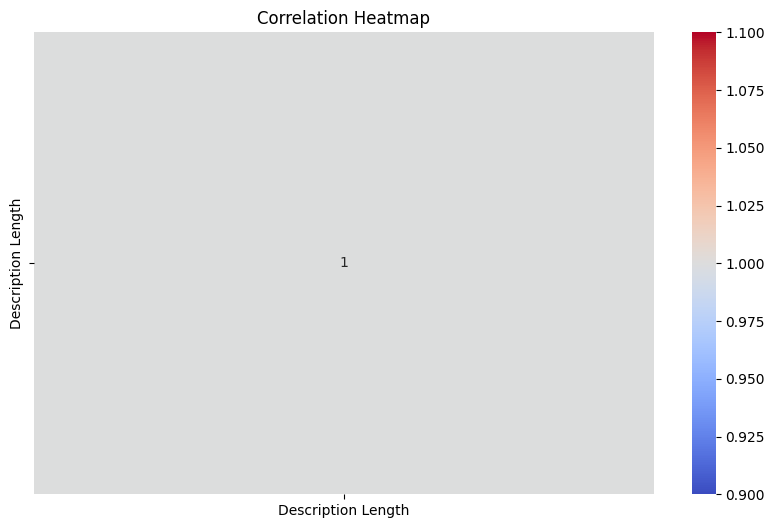

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

# **7_ Label Encoder**

In [ ]:
# it converts text lables to numbers
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(
    df["Ticket Type"]
)

print(encoder.classes_)

['Billing inquiry' 'Cancellation request' 'Product inquiry'
 'Refund request' 'Technical issue']


# **8_Train Test Split**

In [ ]:
# seperating training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    df["Ticket Description"],
    df["Ticket Type"],
    test_size=0.20,
    random_state=42,
    stratify=df["Ticket Type"]
)

In [ ]:
# list of categories
candidate_labels = [
    "Refund request",
    "Technical issue",
    "Cancellation request",
    "Product inquiry",
    "Billing inquiry"
]

# **9_ Zero Shot Classification**

In [ ]:
# using classifier
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [ ]:
# giving ticket to model ro choose best tag
ticket = "I was charged twice for my order"

result = classifier(
    ticket,
    candidate_labels
)

print(result)

{'sequence': 'I was charged twice for my order', 'labels': ['Billing inquiry', 'Product inquiry', 'Refund request', 'Technical issue', 'Cancellation request'], 'scores': [0.4134817123413086, 0.27879875898361206, 0.19484731554985046, 0.07624594867229462, 0.03662623092532158]}


In [ ]:
# it prints the top 3 predicted labels with their confidence scores
for label, score in zip(
    result["labels"][:3],
    result["scores"][:3]
):

    print(
        label,
        round(score,3)
    )

Billing inquiry 0.413
Product inquiry 0.279
Refund request 0.195


In [ ]:
def predict_top3(ticket):

    result = classifier(
        ticket,
        candidate_labels
    )

    return list(
        zip(
            result["labels"][:3],
            result["scores"][:3]
        )
    )

In [ ]:
predict_top3(
    "My payment was deducted twice"
)

[('Billing inquiry', 0.35553935170173645),
 ('Refund request', 0.2030494511127472),
 ('Product inquiry', 0.18118752539157867)]

# **10_ Few Shot Classification**

In [ ]:
# giving examples to train model
def few_shot_predict(text):

    prompt = f"""
Example:
Ticket: I need my money back.
Tag: Refund request

Example:
Ticket: Please cancel my subscription.
Tag: Cancellation request

Example:
Ticket: My device is not working.
Tag: Technical issue

Ticket:
{text}
"""

    result = classifier(
        prompt,
        candidate_labels
    )

    return result["labels"][0]

In [ ]:
# taking predictions
few_shot_predict(
    "I want to stop my subscription immediately"
)

'Cancellation request'

In [ ]:
sample = df.sample(
    200,
    random_state=42
)

# **11_ Predictions**

In [ ]:
# taking predictions
predictions = []

for text in sample["Ticket Description"]:

    pred = classifier(
        text,
        candidate_labels
    )["labels"][0]

    predictions.append(pred)

# **12_ Model Evaluation**

In [ ]:
# checking accuracy
accuracy = accuracy_score(
    sample["Ticket Type"],
    predictions
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.195


In [ ]:
# checking f1 score
f1 = f1_score(
    sample["Ticket Type"],
    predictions,
    average="weighted"
)

print(
    "F1 Score:",
    f1
)

F1 Score: 0.08365239144030237


In [ ]:
# checking classification report
print(
    classification_report(
        sample["Ticket Type"],
        predictions
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.00      0.00      0.00        49
Cancellation request       0.00      0.00      0.00        41
     Product inquiry       0.19      1.00      0.31        36
      Refund request       1.00      0.03      0.05        38
     Technical issue       0.40      0.06      0.10        36

            accuracy                           0.20       200
           macro avg       0.32      0.22      0.09       200
        weighted avg       0.30      0.20      0.08       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# checking confusion matrix
cm = confusion_matrix(
    sample["Ticket Type"],
    predictions
)

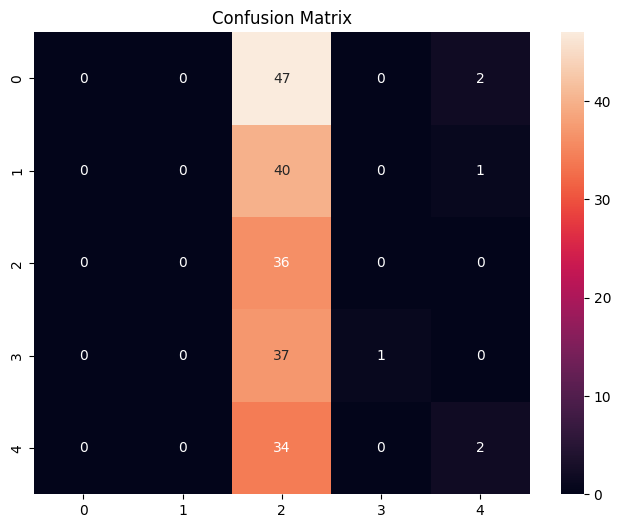

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

# **13_ Comparing Few shots and zero shot**

In [ ]:
comparison_df = pd.DataFrame(
    {
        "Method":[
            "Zero-Shot",
            "Few-Shot"
        ],
        "Description":[
            "No examples provided",
            "Examples provided"
        ]
    }
)

comparison_df

,Method,Description
0,Zero-Shot,No examples provided
1,Few-Shot,Examples provided


In [ ]:
def tag_ticket(ticket):

    result = classifier(
        ticket,
        candidate_labels
    )

    output = ""
# creating a loop to bring three predictions
    for i in range(3):

        output += (
            f"{i+1}. "
            f"{result['labels'][i]}"
            f" "
            f"({result['scores'][i]:.2f})\n"
        )

    return output

# **14_ Gradio**

In [ ]:
demo = gr.Interface(
    fn=tag_ticket,
    inputs="text",
    outputs="text",
    title="Support Ticket Auto Tagger",
    description="Predict top 3 ticket categories using an LLM."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3eb590e0b209903941.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
